In [17]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [18]:
torch.backends.mkldnn.enabled = True

In [19]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [20]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [21]:
model7_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model7_0)
describe(model7_0)

MACs: 7.77 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model7_0.pt
Starting
Epoch 1/60: Train loss = 1.1049, Train accuracy = 0.6075, Test loss = 1.0572, Test accuracy = 0.6245
Epoch 2/60: Train loss = 0.8557, Train accuracy = 0.6967, Test loss = 0.8545, Test accuracy = 0.7012
Epoch 3/60: Train loss = 0.8495, Train accuracy = 0.7008, Test loss = 0.8702, Test accuracy = 0.7000
Epoch 4/60: Train loss = 0.7170, Train accuracy = 0.7480, Test loss = 0.7331, Test accuracy = 0.7486
Epoch 5/60: Train loss = 0.6610, Train accuracy = 0.7727, Test loss = 0.6606, Test accuracy = 0.7732
Epoch 6/60: Train loss = 0.6980, Train accuracy = 0.7567, Test loss = 0.7158, Test accuracy = 0.7556
Epoch 7/60: Train loss = 0.6189, Train accuracy = 0.7882, Test loss = 0.6626, Test accuracy = 0.7742
Epoch 8/60: Train loss = 0.5422, Train accuracy = 0.8089, Test loss = 0.5701, Test accuracy = 0.8030
Epoch 9/60: Train loss = 0.5557, Train accuracy = 0.8081, Test loss = 0.6109, Test accuracy = 0.7977
Epoch 10/60: Train loss = 0.5808

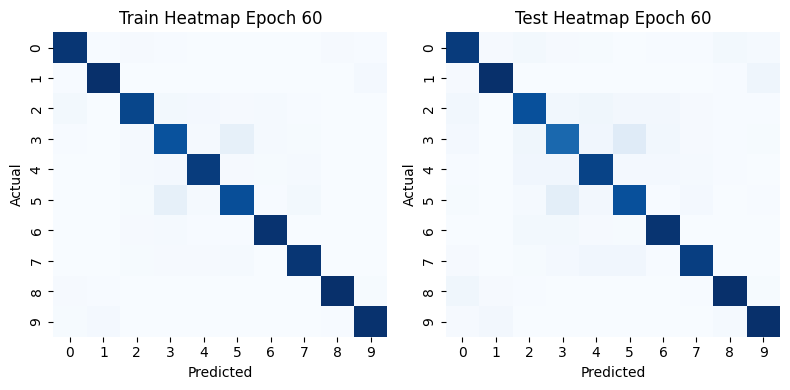

<Figure size 1200x600 with 0 Axes>

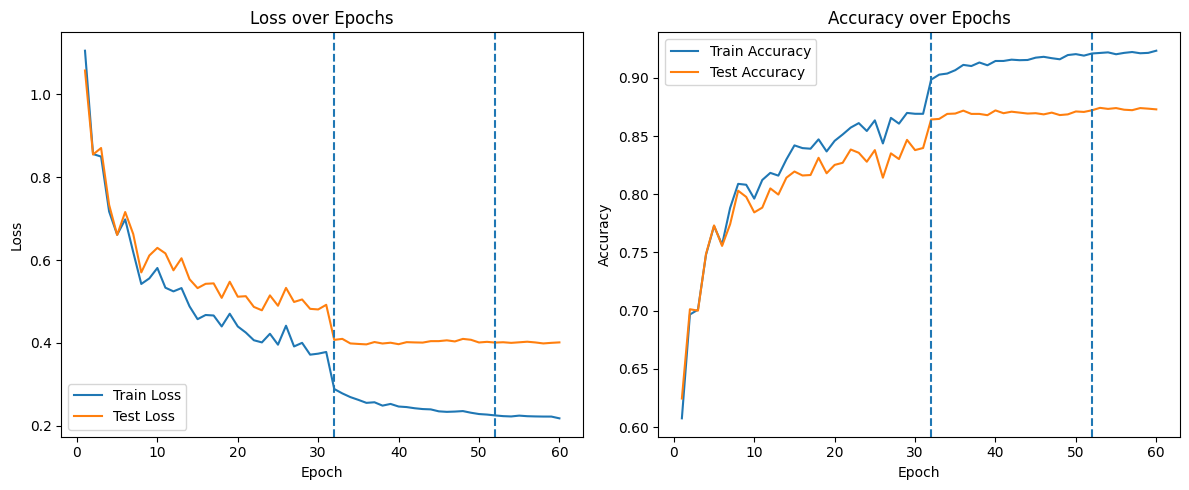

In [22]:
trainf32(model7_0,"model_weights/model7_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [23]:
model7_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model7_1)
describe(model7_1)

MACs: 7.77 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model7_1.pt
Starting
Epoch 1/60: Train loss = 1.1477, Train accuracy = 0.6044, Test loss = 1.1224, Test accuracy = 0.6169
Epoch 2/60: Train loss = 1.0075, Train accuracy = 0.6606, Test loss = 1.0273, Test accuracy = 0.6586
Epoch 3/60: Train loss = 0.7229, Train accuracy = 0.7460, Test loss = 0.7117, Test accuracy = 0.7502
Epoch 4/60: Train loss = 0.8467, Train accuracy = 0.7123, Test loss = 0.8895, Test accuracy = 0.7057
Epoch 5/60: Train loss = 0.6485, Train accuracy = 0.7727, Test loss = 0.6771, Test accuracy = 0.7710
Epoch 6/60: Train loss = 0.6550, Train accuracy = 0.7739, Test loss = 0.6637, Test accuracy = 0.7735
Epoch 7/60: Train loss = 0.6002, Train accuracy = 0.7938, Test loss = 0.6407, Test accuracy = 0.7789
Epoch 8/60: Train loss = 0.5585, Train accuracy = 0.8066, Test loss = 0.6216, Test accuracy = 0.7905
Epoch 9/60: Train loss = 0.5540, Train accuracy = 0.8055, Test loss = 0.5781, Test accuracy = 0.8034
Epoch 10/60: Train loss = 0.5204

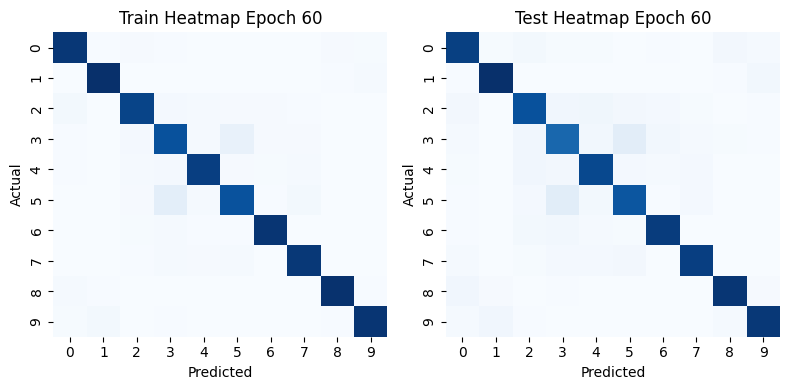

<Figure size 1200x600 with 0 Axes>

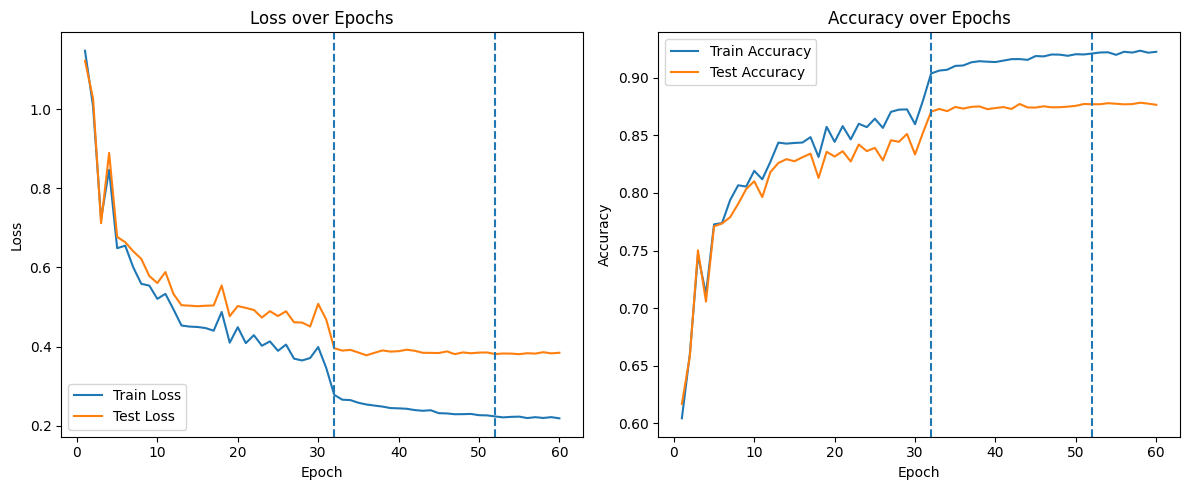

In [24]:
trainf32(model7_1,"model_weights/model7_1.pt",criterion,train_dataset,val_dataset, batch_size=64)